<a href="https://colab.research.google.com/github/medipallysreeya-gif/Machine-learning-skill/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/Colab/Titanic-Dataset.csv')

target_col = "Survived"  # Predict survival

# Drop non-numeric and irrelevant columns
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked", target_col]
feature_df = df.drop(columns=drop_cols, errors="ignore").select_dtypes(include=[np.number])

# Fill missing values with median
feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

# ---------------------------------------------------------
# 2. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. Feature scaling
# ---------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias column (intercept term)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ---------------------------------------------------------
# 4. Gradient Descent implementation
# ---------------------------------------------------------
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)
        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(X_train_b, y_train, lr=0.01, n_iters=1000)

# ---------------------------------------------------------
# 5. Evaluate
# ---------------------------------------------------------
y_pred = X_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

# ---------------------------------------------------------
# 6. Compare with sklearn's LinearRegression
# ---------------------------------------------------------
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print(f"\nsklearn LinearRegression R^2: {r2_score(y_test, sk_pred):.4f}")


Iteration    0 | Loss: 0.1882
Iteration  100 | Loss: 0.1125
Iteration  200 | Loss: 0.1024
Iteration  300 | Loss: 0.1008
Iteration  400 | Loss: 0.1005
Iteration  500 | Loss: 0.1004
Iteration  600 | Loss: 0.1004
Iteration  700 | Loss: 0.1004
Iteration  800 | Loss: 0.1004
Iteration  900 | Loss: 0.1003

Final weights (theta):
[ 0.37638824 -0.15581246 -0.08384079 -0.05242562  0.03759948  0.04210895]

Test MSE : 0.1870
Test R^2 : 0.2287

sklearn LinearRegression R^2: 0.2292


Iteration    0 | Loss: 0.1882
Iteration  100 | Loss: 0.1125
Iteration  200 | Loss: 0.1024
Iteration  300 | Loss: 0.1008
Iteration  400 | Loss: 0.1005
Iteration  500 | Loss: 0.1004
Iteration  600 | Loss: 0.1004
Iteration  700 | Loss: 0.1004
Iteration  800 | Loss: 0.1004
Iteration  900 | Loss: 0.1003

Final weights (theta):
[ 0.37638824 -0.15581246 -0.08384079 -0.05242562  0.03759948  0.04210895]

Test MSE : 0.1870
Test R^2 : 0.2287

sklearn LinearRegression R^2: 0.2292

Saved plots to titanic_gradient_descent.png


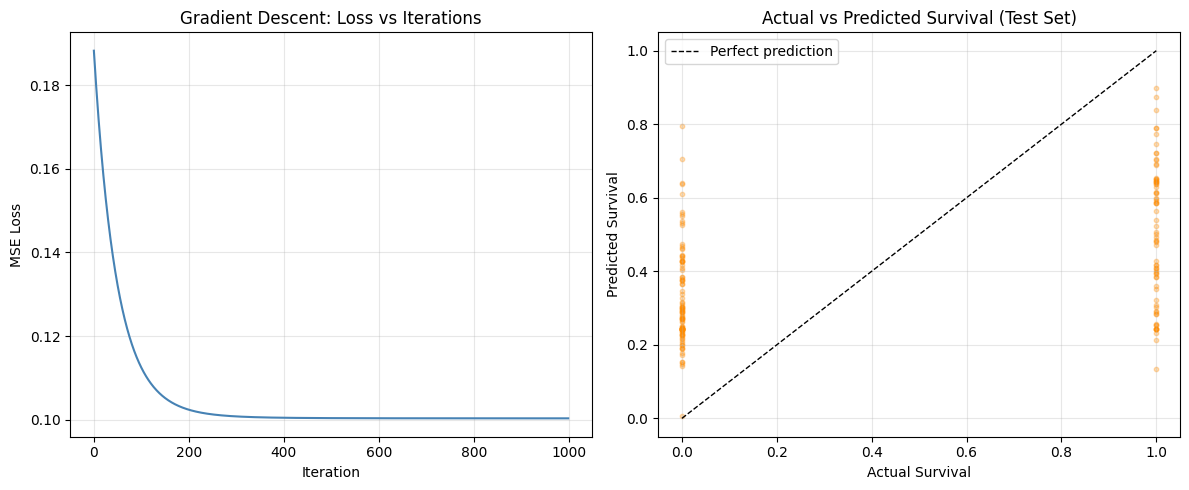

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# 1. Load Titanic dataset
# ---------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab/Titanic-Dataset.csv")

target_col = "Survived"  # Predict survival (0 or 1)

# Drop non-numeric and irrelevant columns
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked", target_col]

feature_df = df.drop(columns=drop_cols, errors="ignore").select_dtypes(include=[np.number])

# Fill missing values with median
feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

# ---------------------------------------------------------
# 2. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. Feature scaling
# ---------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias column (intercept term)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ---------------------------------------------------------
# 4. Gradient Descent implementation
# ---------------------------------------------------------
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)
        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(X_train_b, y_train, lr=0.01, n_iters=1000)

# ---------------------------------------------------------
# 5. Evaluate
# ---------------------------------------------------------
y_pred = X_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

# ---------------------------------------------------------
# 6. Compare with sklearn's LinearRegression
# ---------------------------------------------------------
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print(f"\nsklearn LinearRegression R^2: {r2_score(y_test, sk_pred):.4f}")

# ---------------------------------------------------------
# 7. Plots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Gradient descent loss curve
axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(alpha=0.3)

# (b) Actual vs Predicted Survival
axes[1].scatter(y_test, y_pred, alpha=0.3, s=10, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted Survival (Test Set)")
axes[1].set_xlabel("Actual Survival")
axes[1].set_ylabel("Predicted Survival")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("titanic_gradient_descent.png", dpi=150)
print("\nSaved plots to titanic_gradient_descent.png")
plt.show()
